In [1]:
# моделирование случайных блужданий
# броуновской частицы
# в ограниченной слева  и
# неограниченной областях

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

In [2]:
# Ячейка № 2

# задание функции, возвращающей
# мгновенные усредненные по ансамблю
# независимых реализаций
# значения координат броуновской частицы,
# совершающей случайные блуждания
# в ограниченной слева области
def Walk_left_new(x0, X_min, Step, N_step, N_trial, p):
    # x0 - начальная координата
    #      броуновской частицы
    # X_min - координата отражающей стенки
    # Step - значениe шага метода Монте-Карло
    # N_Step - длина единичной реализации
    #          метода Монте-Карло
    # N_trial - число независимых испытаний
    #           метода Монте-Карло
    # p - пороговая вероятность

    # инициализация массивов, используемых для хранения
    # ансамблей траекторий броуновских частиц,
    # движущихся в ограниченной слева (X_L) и
    # неограниченной областях (X_N)
    X_L = np.zeros([N_step, N_trial + 1])
    X_N = np.zeros([N_step, N_trial + 1])

    # размещение координат начальных точек
    # траекторий броуновских частиц
    # в массивах X_L, X_N
    X_L[:, 0] = x0
    X_N[:, 0] = x0

    # вычисление ансамблей траекторий
    # броуновских частиц, движущихся
    # в ограниченной слева (X_L) и
    # неограниченной областях (X_N)
    # в соответствие с методом Монте-Карло
    for i in range(1, N_trial + 1):
        x_L = x0
        x_N = x0
        for j in range(N_step):
            if p < random.uniform(0, 1):
                x_L = x_L - Step
                x_N = x_N - Step
                if x_L < X_min:
                    x_L = 2 * X_min - x_L
            else:
                x_L = x_L + Step
                x_N = x_N + Step
            X_L[j, i] = x_L
            X_N[j, i] = x_N

    # инициализация массивов,
    # используемых для хранения
    # мгновенных усредненных по ансамблям
    # независимых реализаций
    # значений координат и
    # среднеквадратических отклонений
    # броуновских частиц
    d_L = np.zeros(N_step)
    d_N = np.zeros(N_step)
    m_L = np.zeros(N_step)
    m_N = np.zeros(N_step)

    # вычисление мгновенных
    # усредненных по ансамблям
    # независимых реализаций
    # значений координат и
    # среднеквадратических отклонений
    # броуновских частиц
    for i in range(N_step):
        # вычисление средних
        # по ансамблю траекторий
        # мгновенных значений координат
        # броуновской частицы, совершающей
        # движение в области, ограниченной слева
        m_L[i] = np.mean(X_L[i, :])

        # вычисление средних
        # по ансамблю траекторий
        # мгновенных значений координат
        # броуновской частицы, совершающей
        # движение в неограниченной области
        m_N[i] = np.mean(X_N[i, :])

        # вычисление мгновенных значений
        # среднеквадратического отклонения
        # значений координат ансамбля траекторий
        # броуновской частицы, совершающей
        # движение в области, ограниченной слева
        d_L[i] = np.var(X_L[i, :] - m_L[i])

        # вычисление мгновенных значений
        # среднеквадратического отклонения
        # значений координат ансамбля траекторий
        # броуновской частицы, совершающей
        # движение в неограниченной области
        d_N[i] = np.var(X_N[i, :] - m_N[i])

    return d_L, d_N, m_L, m_N

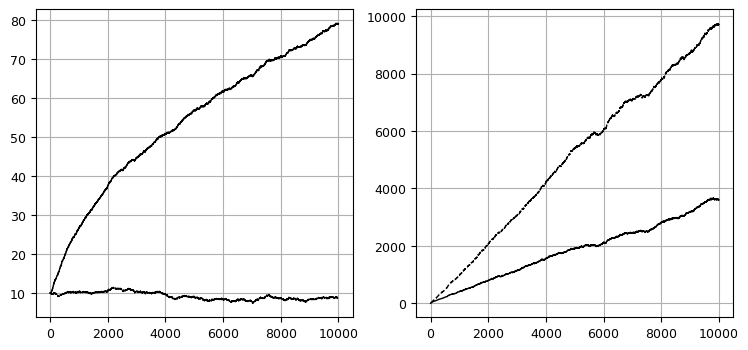

In [ ]:
# Ячейка № 3

# инициализация генератора случайных чисел
random.seed()

# задание начальной координаты
# броуновской частицы
x0 = 10

# задание координаты отражающей стенки
X_min = 0

# задание значения шага
# броуновской частицы
Step = 1

# задание числа шагов
# броуновской частицы
N_step = 10**4

# задание числа
# независимых испытаний
# в методе Монте-Карло
N_trial = 10**3

# задание порогового
# значения вероятности
p = 0.5

# вычисление мгновенных
# усредненных по ансамблям
# независимых реализаций
# значений координат и
# среднеквадратических отклонений
# броуновских частиц
[dL, dN, mL, mN] = Walk_left_new(x0, X_min, Step, N_step, N_trial, p)

# визуализация зависимостей
# мгновенных усредненных по ансамблям
# независимых реализаций
# значений координат и
# среднеквадратических отклонений
# броуновских частиц от времени
fig = plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
# визуализация зависимостей
# мгновенных усредненных по ансамблям
# независимых реализаций
# значений координат
plt.plot(mL, color="black", linewidth=1)
plt.plot(mN, "--", color="black", linewidth=1)
# plt.ylim([0,0.05])
plt.grid(True)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.subplot(1, 2, 2)
# визуализация зависимостей
# среднеквадратических отклонений
# броуновских частиц от времени
plt.plot(dL, color="black", linewidth=1)
plt.plot(dN, "--", color="black", linewidth=1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.grid(True)
plt.show()

In [4]:
# Ячейка № 4

# моделирование случайных блужданий
# броуновской частицы
# в ограниченной слева
# и неограниченной областях

# инициализация генератора случайных чисел
random.seed()


# задание функции, возвращающей
# мгновенные усредненные по ансамблю
# независимых реализаций
# значения координат броуновской частицы,
# совершающей случайные блуждания
# в ограниченной слева и неограниченной областях
def Walk_left_new_mod(x0, X_max, Step, N_step, N_trial, p):
    # x0 - начальная координата
    #      броуновской частицы
    # X_min - координата отражающей стенки
    # Step - значениe шага метода Монте-Карло
    # N_Step - длина единичной реализации
    #          метода Монте-Карло
    # N_trial - число независимых испытаний
    #           метода Монте-Карло
    # p - пороговая вероятность

    # инициализация массивов, используемых для хранения
    # ансамблей траекторий броуновских частиц,
    # движущихся в ограниченной слева (new_L) и
    # неограниченной областях (new_N)
    new_L = np.zeros(N_trial + 1)
    new_N = np.zeros(N_trial + 1)

    # инициализация массивов, используемых для хранения
    # мгновенных значений вычисляемых зависимостей
    m_L = np.zeros(N_step)
    m_N = np.zeros(N_step)
    d_L = np.zeros(N_step)
    d_N = np.zeros(N_step)

    # размещение значения
    # начальной координаты частицы
    # в массивах new_L, new_N
    new_L[:] = x0
    new_N[:] = x0

    # размещение среднего значения
    # ансамбля координат броуновских частиц
    # в массивах m_L, m_N, вычисленных
    # в момент времени t = 0
    m_L[0] = np.mean(new_L)
    m_N[0] = np.mean(new_N)

    # размещение среднего значения
    # ансамбля координат броуновских частиц
    # в массивах m_L, m_N, вычисленных
    # в момент времени t = 0
    d_L[0] = np.var(new_L)
    d_N[0] = np.var(new_N)

    # вычисление мгновенных значений
    # усредненных по ансамблю реализаций
    # значений координат и
    # среднеквадратических отклонений
    # броуновских частиц, блуждающих
    # в ограниченной слева и неограниченной областях
    for j in range(1, N_step):
        # вычисление мгновенных значений
        # на j-ом шаге броуновской частицы
        for i in range(1, N_trial + 1):
            # вычиcление ансамбля значений
            # броуновских частиц на их j-ом шаге
            if p < random.uniform(0, 1):
                new_L[i] = new_L[i] - Step
                new_N[i] = new_N[i] - Step
                if new_L[i] < X_min:
                    new_L[i] = 2 * X_min - new_L[i]
            else:
                new_L[i] = new_L[i] + Step
                new_N[i] = new_N[i] + Step

        # вычисление средних
        # по ансамблю мгновенных значений координат
        # броуновской частицы, совершающей
        # движение в области, ограниченной слева
        # на j-ом шаге броуновских частиц
        m_L[j] = np.mean(new_L)

        # вычисление средних
        # по ансамблю траекторий
        # мгновенных значений координат
        # броуновской частицы, совершающей
        # движение в неограниченной области
        # на j-ом шаге броуновских частиц
        m_N[j] = np.mean(new_N)

        # вычисление мгновенных значений
        # среднеквадратического отклонения
        # значений координат ансамбля траекторий
        # броуновской частицы, совершающей
        # движение в области, ограниченной слева
        # на j-ом шаге броуновских частиц
        d_L[j] = np.var(new_L - m_L[j])

        # вычисление мгновенных значений
        # среднеквадратического отклонения
        # значений координат ансамбля траекторий
        # броуновской частицы, совершающей
        # движение в неограниченной области
        # на j-ом шаге броуновских частиц
        d_N[j] = np.var(new_N - m_N[j])

    return m_L, m_N, d_L, d_N

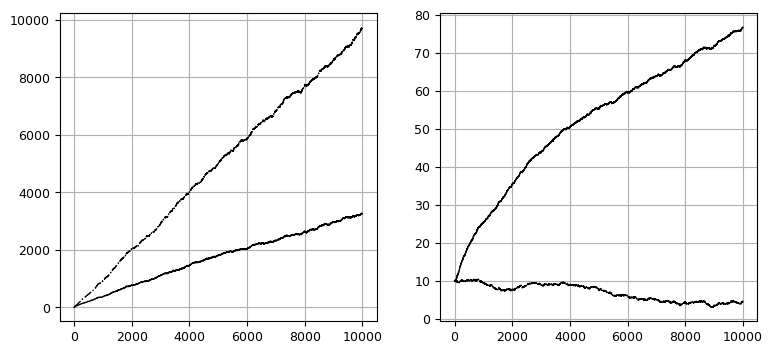

In [ ]:
# Ячейка № 5

# задание начальной координаты
# броуновской частицы
x0 = 10

# задание координаты отражающей стенки
X_min = 0

# задание значения шага
# броуновской частицы
Step = 1

# задание числа шагов
# броуновской частицы
N_step = 10**4

# задание числа
# независимых испытаний
# в методе Монте-Карло
N_trial = 10**3

# задание порогового
# значения вероятности
p = 0.5

# вычисление мгновенных
# усредненных по ансамблям
# независимых реализаций
# значений координат и
# среднеквадратических отклонений
# броуновских частиц
[dL, dN, mL, mN] = Walk_left_new_mod(x0, X_min, Step, N_step, N_trial, p)

# визуализация зависимостей
# мгновенных усредненных по ансамблям
# независимых реализаций
# значений координат и
# среднеквадратических отклонений
# броуновских частиц от времени
fig = plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
# визуализация зависимостей
# мгновенных усредненных по ансамблям
# независимых реализаций
# значений координат
plt.plot(mL, color="black", linewidth=1)
plt.plot(mN, "-.", color="black", linewidth=1)
plt.grid(True)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.subplot(1, 2, 2)
# визуализация зависимостей
# среднеквадратических отклонений
# броуновских частиц от времени
plt.plot(dL, color="black", linewidth=1)
plt.plot(dN, "-.", color="black", linewidth=1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.grid(True)
plt.show()